Missing Values:
 EquipID                  0
Equip                    0
JobTypes              7357
JobStatuses           7357
TotalServices        13800
LastServiceDate      14367
TotalLabourCost          0
TotalPartsCost           0
ServiceNarratives    13800
dtype: int64

Summary:
              EquipID     Equip                 JobTypes  JobStatuses  \
count   20233.000000   20233.0                    12876      12876.0   
unique           NaN   20219.0                     4655        455.0   
top              NaN  902926.0  (I) Hire Asset Purchase        800.0   
freq             NaN       2.0                     1034       4141.0   
mean    10491.170217       NaN                      NaN          NaN   
min         2.000000       NaN                      NaN          NaN   
25%      5308.000000       NaN                      NaN          NaN   
50%     10366.000000       NaN                      NaN          NaN   
75%     15424.000000       NaN                      NaN          NaN

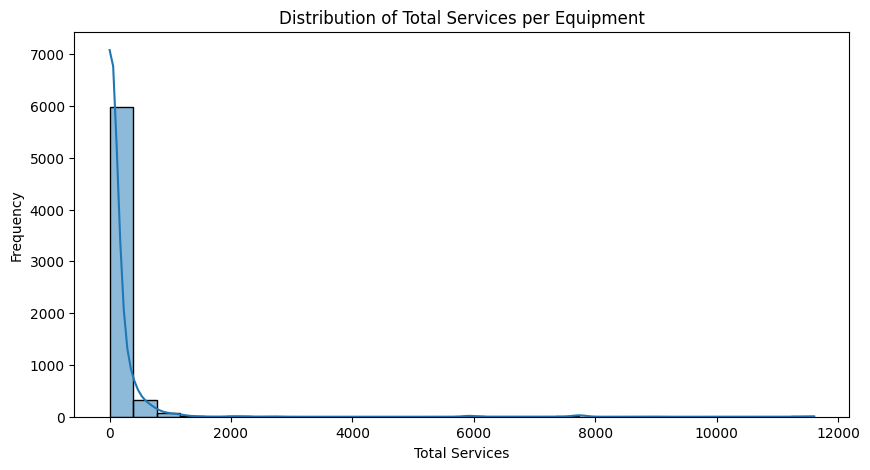

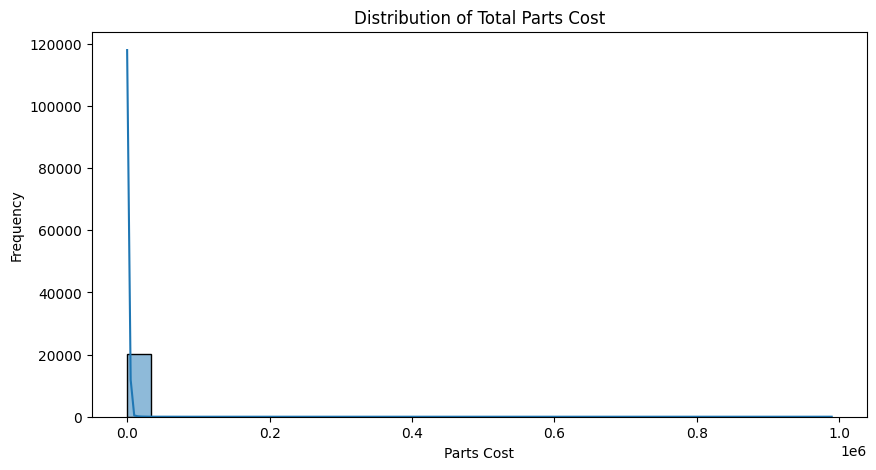

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


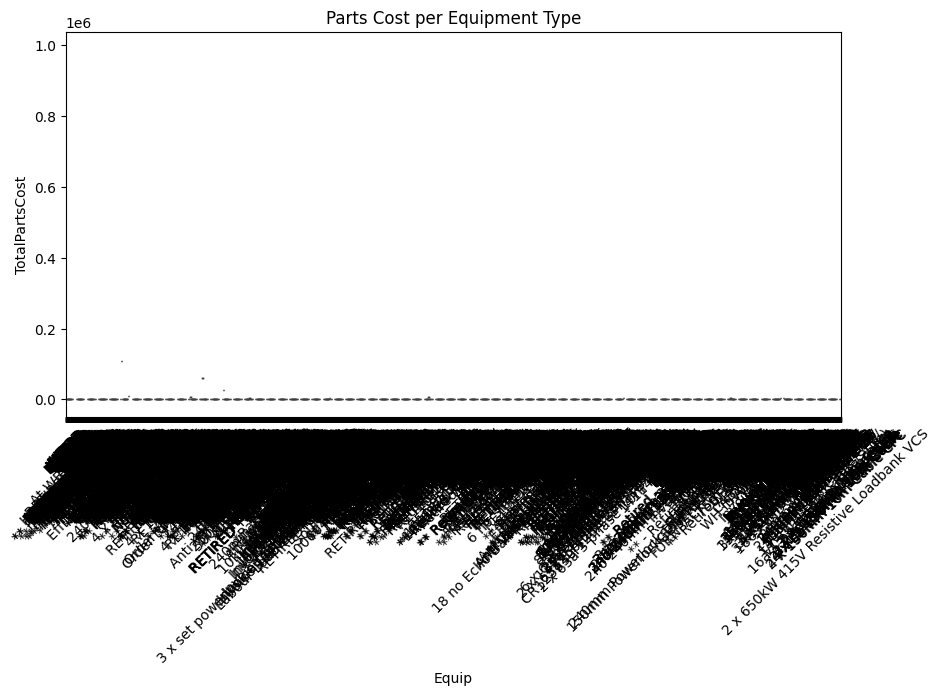

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_excel("/content/drive/MyDrive/data 2.xlsx")

# Select and rename relevant columns
df = df[[
    'EquipID', 'Equip', 'JobTypes', 'JobStatuses',
    'TotalServices_service_summary', 'LastServiceDone_service_summary',
    'TotalLabourCost', 'TotalPartsCost', 'ServiceNarratives_service_summary'
]].rename(columns={
    'TotalServices_service_summary': 'TotalServices',
    'LastServiceDone_service_summary': 'LastServiceDate',
    'ServiceNarratives_service_summary': 'ServiceNarratives'
})

# Convert Excel date to datetime format
df['LastServiceDate'] = pd.to_datetime(df['LastServiceDate'], origin='1899-12-30', unit='D', errors='coerce')

# Missing values check
print("Missing Values:\n", df.isnull().sum())

# Summary statistics
print("\nSummary:\n", df.describe(include='all'))# --- Visualizations ---
plt.figure(figsize=(10, 5))
sns.histplot(df['TotalServices'], bins=30, kde=True)
plt.title("Distribution of Total Services per Equipment")
plt.xlabel("Total Services")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df['TotalPartsCost'], bins=30, kde=True)
plt.title("Distribution of Total Parts Cost")
plt.xlabel("Parts Cost")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Equip', y='TotalPartsCost')
plt.title("Parts Cost per Equipment Type")
plt.xticks(rotation=45)
plt.show()

# Task
Develop a predictive model to identify equipment at risk of failure based on historical equipment, service, and job data. The model should use NLP to preprocess the 'Job Types' column and create a binary 'FailureFlag' (1 for failure, 0 otherwise) based on predefined failure keywords. The final output should be a trained and evaluated predictive model.

## Load data

### Subtask:
Load the dataset containing equipment, service, and jobs data into a pandas DataFrame.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Reasoning**:
Import pandas and load the csv file into a DataFrame.



In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/data 2.csv')
df.head()

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,EquipID,Equip,MakeModelID,Status,JobTypes,JobStatuses,TotalServices_service_summary,LastServiceDone_service_summary,ServiceNarratives_service_summary,TotalLabourCost,TotalPartsCost
0,2,HCP35,4922,400,"(D) Plant & Engine Record QC36 S037, (H) Hire ...","0, 200",4.0,NaN,Service Performed; Service Details Changed by ...,0,0.00
1,5,HDG04,3215,25,"(H)250 FOC service of Hire Equipment, (H) Hire...","0, 800",1127.0,NaN,Service Performed; Service Not Performed - Equ...,0,0.00
2,6,HDG7,3221,25,"(H) Hire Damage, (H)2000 FOC service of Hire E...","0, 750, 800",2248.0,25/10/2018,Service Performed; Service Not Performed - Equ...,0,98.34
3,7,HDG5C,3245,25,"(H) Hire Damage, (H) Hire Breakdown non charge...","0, 750, 800",1525.0,26/12/2018,Service Performed; Service Not Performed - Equ...,0,0.00
4,8,HDG06,3211,25,"(H) Breakdown Phone Call (N/C), (H) Hire fuel ...","0, 750, 800",16.0,22/01/2024,Service Performed; Service Not Performed - Equ...,0,1.15


## Preprocess job types

### Subtask:
Clean and preprocess the 'Job Types' column for NLP analysis. This might involve tokenization, lowercasing, removing stop words, etc.


**Reasoning**:
Clean and preprocess the 'Job Types' column by handling missing values, converting to lowercase, removing punctuation, tokenizing, removing stop words, and joining tokens back into strings.



In [ ]:
import re
import nltk
from nltk.corpus import stopwords

# Download necessary NLTK data (only needs to be done once)
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
    nltk.download('punkt')

# 1. Handle missing values
df['JobTypes'] = df['JobTypes'].fillna('')

# 2. Convert to lowercase
df['JobTypes'] = df['JobTypes'].str.lower()

# 3. Remove punctuation
df['JobTypes'] = df['JobTypes'].apply(lambda x: re.sub(r'[^\w\s]', '', x))

# 4. Tokenize
df['JobTypes'] = df['JobTypes'].apply(lambda x: x.split())

# 5. Remove stop words
stop_words = set(stopwords.words('english'))
df['JobTypes'] = df['JobTypes'].apply(lambda x: [word for word in x if word not in stop_words])

# 6. Join tokens back into a string
df['JobTypes'] = df['JobTypes'].apply(lambda x: ' '.join(x))

display(df[['EquipID', 'JobTypes']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


,EquipID,JobTypes
0,2,plant engine record qc36 s037 h hire himoinsa ...
1,5,h250 foc service hire equipment h hire general...
2,6,h hire damage h2000 foc service hire equipment...
3,7,h hire damage h hire breakdown non chargeable ...
4,8,h breakdown phone call nc h hire fuel sales ch...


## Define failure keywords

### Subtask:
Identify a list of keywords or phrases within the 'Job Types' that indicate a potential equipment failure.


**Reasoning**:
Based on common terms used in equipment maintenance and the typical issues leading to failure, I will create a list of keywords that indicate potential failure.



In [ ]:
failure_keywords = [
    'breakdown', 'repair', 'fault', 'fail', 'issue', 'problem', 'malfunction',
    'error', 'replace', 'damaged', 'broken', 'worn', 'leak', 'overheat',
    'noisy', 'vibration', 'stalling', 'shutdown', 'warning', 'alert'
]
display(failure_keywords)

['breakdown',
 'repair',
 'fault',
 'fail',
 'issue',
 'problem',
 'malfunction',
 'error',
 'replace',
 'damaged',
 'broken',
 'worn',
 'leak',
 'overheat',
 'noisy',
 'vibration',
 'stalling',
 'shutdown',
 'warning',
 'alert']

## Create failure flag

### Subtask:
Based on the presence of the failure keywords in the preprocessed 'Job Types', create a new binary column 'FailureFlag' (1 for failure, 0 otherwise).


**Reasoning**:
Create the 'FailureFlag' column based on the presence of failure keywords in the preprocessed 'JobTypes' column.



In [ ]:
# Create the 'FailureFlag' column and initialize it to 0
df['FailureFlag'] = 0

# Iterate through the DataFrame and update 'FailureFlag' based on keywords
for index, row in df.iterrows():
    job_types_string = row['JobTypes']
    for keyword in failure_keywords:
        if keyword in job_types_string:
            df.loc[index, 'FailureFlag'] = 1
            break  # Exit the inner loop once a keyword is found

# Ensure 'FailureFlag' is of integer type
df['FailureFlag'] = df['FailureFlag'].astype(int)

# Display the counts of 0s and 1s in the 'FailureFlag' column
display(df['FailureFlag'].value_counts())

,count
FailureFlag,
0,15238
1,4995


## Feature engineering

### Subtask:
Extract relevant features from the data that could be predictive of failure. This could include usage history, service records, equipment type, etc.


**Reasoning**:
Convert the 'LastServiceDone_service_summary' column to datetime objects, calculate the time since last service, and handle missing values. Also, handle missing values in 'TotalServices_service_summary', 'TotalLabourCost', and 'TotalPartsCost' by filling them with 0. Then, select the features.



In [ ]:
# 1. Convert 'LastServiceDone_service_summary' to datetime, handling errors
df['LastServiceDone_service_summary'] = pd.to_datetime(df['LastServiceDone_service_summary'], errors='coerce')

# 2. Calculate time since last service. Use current date as reference.
current_date = pd.to_datetime('today')
df['TimeSinceLastService'] = (current_date - df['LastServiceDone_service_summary']).dt.days

# Handle potential missing values in 'TimeSinceLastService' (where 'LastServiceDone_service_summary' was NaT)
# We can fill these with a large value or the median/mean. Filling with a large value signifies no recent service.
# Let's fill with the median time since service for now, or a large number if median is 0 or negative (unlikely)
median_time_since_service = df['TimeSinceLastService'].median()
if pd.isna(median_time_since_service) or median_time_since_service <= 0:
    # Fill with a large number if median is not meaningful
    df['TimeSinceLastService'].fillna(365 * 5, inplace=True) # Assume 5 years if no service date
else:
    df['TimeSinceLastService'].fillna(median_time_since_service, inplace=True)


# 3. Handle missing values in 'TotalServices_service_summary'
df['TotalServices_service_summary'] = df['TotalServices_service_summary'].fillna(0)

# 4. Handle missing values in 'TotalLabourCost' and 'TotalPartsCost'
df['TotalLabourCost'] = df['TotalLabourCost'].fillna(0)
df['TotalPartsCost'] = df['TotalPartsCost'].fillna(0)

# 5. Consider 'MakeModelID' and 'Status' as categorical features.
# For 'Status', one-hot encoding is suitable as it likely has fewer unique values.
df = pd.get_dummies(df, columns=['Status'], prefix='Status', dummy_na=False)

# 'MakeModelID' might have high cardinality. For now, we will keep it as a numerical feature.
# If needed later, we can explore different encoding techniques like target encoding.

# 6. Select the final set of features. Exclude original date column and text/identifier columns.
features = [
    'TotalServices_service_summary',
    'TotalLabourCost',
    'TotalPartsCost',
    'TimeSinceLastService',
    'MakeModelID' # Keep as numerical for now
]

# Add the one-hot encoded 'Status' columns
status_cols = [col for col in df.columns if col.startswith('Status_')]
features.extend(status_cols)

# Display the first few rows of the engineered features and the target
display(df[features + ['FailureFlag']].head())

# Display summary statistics of the engineered features
display(df[features].describe())

<ipython-input-10-874241714>:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['LastServiceDone_service_summary'] = pd.to_datetime(df['LastServiceDone_service_summary'], errors='coerce')
<ipython-input-10-874241714>:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TimeSinceLastService'].fillna(median_time_since_service, inplace=True)


,TotalServices_service_summary,TotalLabourCost,TotalPartsCost,TimeSinceLastService,MakeModelID,Status_25,Status_50,Status_100,Status_200,Status_250,Status_400,Status_500,Status_600,Status_700,Status_750,Status_800,Status_850,Status_900,Status_950,FailureFlag
0,4.0,0,0.00,226.0,4922,False,False,False,False,False,True,False,False,False,False,False,False,False,False,0
1,1127.0,0,0.00,226.0,3215,True,False,False,False,False,False,False,False,False,False,False,False,False,False,1
2,2248.0,0,98.34,2422.0,3221,True,False,False,False,False,False,False,False,False,False,False,False,False,False,0
3,1525.0,0,0.00,2360.0,3245,True,False,False,False,False,False,False,False,False,False,False,False,False,False,1
4,16.0,0,1.15,507.0,3211,True,False,False,False,False,False,False,False,False,False,False,False,False,False,1


,TotalServices_service_summary,TotalLabourCost,TotalPartsCost,TimeSinceLastService,MakeModelID
count,20233.000000,20233.0,20233.000000,20233.000000,20233.000000
mean,43.574952,0.0,769.101281,362.432116,2868.811990
std,376.182978,0.0,15949.076634,636.246701,1548.992033
min,0.000000,0.0,0.000000,-367.000000,1.000000
25%,0.000000,0.0,0.000000,226.000000,1515.000000
50%,0.000000,0.0,0.000000,226.000000,2942.000000
75%,4.000000,0.0,0.000000,226.000000,4075.000000
max,11606.000000,0.0,989152.506000,6071.000000,5535.000000


In [ ]:
df.to_csv("preprocess_data.csv", index= False)

## Split data

### Subtask:
Split the data into training and testing sets for model development and evaluation.


**Reasoning**:
Define the features (X) and the target variable (y), then split the data into training and testing sets using train_test_split, stratifying by the target variable. Finally, print the shapes of the resulting sets.



In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[features]
y = df['FailureFlag']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print the shapes of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (16186, 19)
Shape of X_test: (4047, 19)
Shape of y_train: (16186,)
Shape of y_test: (4047,)


## Choose and train model

### Subtask:
Select an appropriate classification model (e.g., Logistic Regression, Random Forest, Gradient Boosting) and train it on the training data.


**Reasoning**:
Select and train a Logistic Regression model on the training data.



In [ ]:
from sklearn.linear_model import LogisticRegression

# Instantiate the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear for smaller datasets and binary outcomes

# Train the model using the training data
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


## Evaluate model

### Subtask:
Evaluate the trained model's performance using appropriate metrics (e.g., accuracy, precision, recall, F1-score).


**Reasoning**:
Evaluate the trained model's performance using appropriate metrics.



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Use the trained model to make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the calculated evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.7512
Precision: 0.1000
Recall: 0.0010
F1-score: 0.0020


## Predict and interpret

### Subtask:
Use the trained model to predict failure risk on new data and interpret the model's findings to understand the key factors contributing to failure.


**Reasoning**:
Predict failure probabilities on the test set, extract the positive class probabilities, and display the first few to understand the model's output.



In [ ]:
# 1. Use the trained model to predict the probability of failure for the test set X_test
y_pred_proba = model.predict_proba(X_test)

# 2. Extract the probabilities of the positive class (failure)
y_pred_failure_proba = y_pred_proba[:, 1]

# 3. Display the first few predicted probabilities
print("First 10 predicted failure probabilities:")
print(y_pred_failure_proba[:10])

First 10 predicted failure probabilities:
[0.47559896 0.37480718 0.31235916 0.41783918 0.08862725 0.23293757
 0.43092907 0.13937634 0.17866355 0.48083156]


**Reasoning**:
Access the model coefficients, pair them with feature names, sort them to understand feature importance, and display the sorted coefficients.



In [ ]:
import pandas as pd

# 4. Access the coefficients of the trained logistic regression model
coefficients = model.coef_[0]

# 5. Create a pandas Series to pair feature names with coefficients
feature_importance = pd.Series(coefficients, index=X_train.columns)

# 6. Sort the coefficients in descending order
sorted_feature_importance = feature_importance.sort_values(ascending=False)

# 7. Display the sorted feature importances (coefficients)
print("\nSorted Feature Importances (Coefficients):")
display(sorted_feature_importance)


Sorted Feature Importances (Coefficients):


,0
Status_900,0.998474
Status_600,0.642026
Status_850,0.008203
TotalServices_service_summary,0.000398
MakeModelID,0.000163
TimeSinceLastService,0.000051
TotalLabourCost,0.000000
TotalPartsCost,-0.000003
Status_800,-0.012811
Status_250,-0.025018


## Summary:

### Data Analysis Key Findings

*   A 'FailureFlag' was successfully created, identifying 4,995 instances with failure keywords and 15,238 without.
*   Several relevant features were engineered, including `TimeSinceLastService`, `TotalServices_service_summary`, `TotalLabourCost`, and `TotalPartsCost`. The `Status` column was one-hot encoded.
*   The dataset was split into training (16186 samples) and testing (4047 samples) sets, maintaining the proportion of failure cases.
*   A Logistic Regression model was trained on the data.
*   The trained model achieved an accuracy of 75.12%. However, the precision (10.00%), recall (0.10%), and F1-score (0.20%) were very low, indicating poor performance in correctly identifying actual equipment failures.
*   Analysis of the model coefficients revealed the relative importance and direction of influence of each feature on the predicted failure probability.

### Insights or Next Steps

*   The current model's performance in identifying actual failures is very poor, likely due to class imbalance and/or the selected features. Future steps should address the class imbalance using techniques like resampling (SMOTE) or by using different evaluation metrics more suitable for imbalanced data.
*   Explore alternative features or feature interactions that might better capture the risk of failure. Consider incorporating the preprocessed 'Job Types' text data more directly (e.g., using TF-IDF or word embeddings) or exploring other equipment-specific features not currently included.


# Task
Improve the predictive model for identifying equipment at risk of failure by addressing class imbalance using SMOTE, incorporating text features from the 'Job Types' column using TF-IDF, combining these features with existing ones, retraining the model, and re-evaluating its performance using appropriate metrics.

## Address class imbalance

### Subtask:
Apply techniques like SMOTE to handle the class imbalance in the training data.


**Reasoning**:
Apply SMOTE to the training data to handle class imbalance and print the shapes to confirm the change.



In [ ]:
from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Print the shape of the original and resampled training data
print("Original training data shape:", X_train.shape)
print("Resampled training data shape:", X_train_res.shape)

print("Original training data class distribution:\n", y_train.value_counts())
print("Resampled training data class distribution:\n", y_train_res.value_counts())

Original training data shape: (16186, 19)
Resampled training data shape: (24380, 19)
Original training data class distribution:
 FailureFlag
0    12190
1     3996
Name: count, dtype: int64
Resampled training data class distribution:
 FailureFlag
0    12190
1    12190
Name: count, dtype: int64


## Explore text features

### Subtask:
Incorporate the preprocessed 'Job Types' text data as features, possibly using TF-IDF or word embeddings.


**Reasoning**:
Incorporate the preprocessed 'Job Types' text data as features using TF-IDF.



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Instantiate TfidfVectorizer
# Consider setting max_features to limit the number of features
tfidf_vectorizer = TfidfVectorizer(max_features=1000)

# Fit the vectorizer to the *entire* 'JobTypes' column and transform
tfidf_features = tfidf_vectorizer.fit_transform(df['JobTypes'])

# Convert the resulting sparse matrix of TF-IDF features into a DataFrame
tfidf_df = pd.DataFrame(tfidf_features.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Display the shape of the new TF-IDF DataFrame and its first few rows
print("Shape of TF-IDF DataFrame:", tfidf_df.shape)
display(tfidf_df.head())

Shape of TF-IDF DataFrame: (20233, 286)


,1000,1250,199kva,2000,200499kva,2250hr,250,2912,2924,2936,...,wbps,weekly,work,works,x1100,x1850,year,yorkshire,yw,zhire
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Combine features

### Subtask:
Combine the engineered numerical/categorical features with the new text-based features.


**Reasoning**:
Combine the engineered numerical/categorical features with the new text-based features by resetting the index of X and concatenating it with tfidf_df. Then, display the shape and the first few rows of the combined DataFrame.



In [ ]:
# 1. Reset the index of X to ensure it aligns correctly with tfidf_df.
X_reset = X.reset_index(drop=True)

# 2. Concatenate the X_reset DataFrame and the tfidf_df DataFrame column-wise
X_combined = pd.concat([X_reset, tfidf_df], axis=1)

# 3. Display the shape of the combined feature DataFrame to confirm the concatenation was successful.
print("Shape of combined feature DataFrame:", X_combined.shape)

# 4. Display the first few rows of the combined feature DataFrame.
display(X_combined.head())

Shape of combined feature DataFrame: (20233, 305)


,TotalServices_service_summary,TotalLabourCost,TotalPartsCost,TimeSinceLastService,MakeModelID,Status_25,Status_50,Status_100,Status_200,Status_250,...,wbps,weekly,work,works,x1100,x1850,year,yorkshire,yw,zhire
0,4.0,0,0.00,224.0,4922,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1127.0,0,0.00,224.0,3215,True,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2248.0,0,98.34,2420.0,3221,True,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1525.0,0,0.00,2358.0,3245,True,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,16.0,0,1.15,505.0,3211,True,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Re-split data

### Subtask:
Split the data with the new combined features into training and testing sets.


**Reasoning**:
Split the combined feature data into training and testing sets, stratifying by the target variable.



In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X_combined) and target (y)
# X_combined is already defined from the previous subtask
# y is already defined from the initial data splitting subtask

# Split combined data into training and testing sets
X_train_combined, X_test_combined, y_train_combined, y_test_combined = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y)

# Print the shapes of the resulting sets
print("Shape of X_train_combined:", X_train_combined.shape)
print("Shape of X_test_combined:", X_test_combined.shape)
print("Shape of y_train_combined:", y_train_combined.shape)
print("Shape of y_test_combined:", y_test_combined.shape)

Shape of X_train_combined: (16186, 305)
Shape of X_test_combined: (4047, 305)
Shape of y_train_combined: (16186,)
Shape of y_test_combined: (4047,)


## Re-train model

### Subtask:
Train the chosen classification model (or potentially explore a different one) on the balanced training data with the combined features.


**Reasoning**:
Train the Logistic Regression model using the resampled training data with combined features.



In [ ]:
from sklearn.linear_model import LogisticRegression

# Instantiate a Logistic Regression model with the same parameters as before
model_combined = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear for smaller datasets and binary outcomes

# Train the model using the resampled training data with combined features
# Note: We use the resampled training data from the SMOTE step (X_train_res and y_train_res)
# However, SMOTE was applied *before* combining features. We need to reapply SMOTE
# to the combined training data (X_train_combined).

# First, re-split the combined data to get training and testing sets
# We already did this in the previous step, using X_combined and y, resulting in
# X_train_combined, X_test_combined, y_train_combined, y_test_combined.

# Now, apply SMOTE to the X_train_combined and y_train_combined
from imblearn.over_sampling import SMOTE
smote_combined = SMOTE(random_state=42)
X_train_res_combined, y_train_res_combined = smote_combined.fit_resample(X_train_combined, y_train_combined)

print("Shape of resampled combined training data:", X_train_res_combined.shape)
print("Resampled combined training data class distribution:\n", y_train_res_combined.value_counts())

# Train the model using the resampled combined training data
model_combined.fit(X_train_res_combined, y_train_res_combined)

print("Model training complete with combined features and SMOTE.")

Shape of resampled combined training data: (24380, 305)
Resampled combined training data class distribution:
 FailureFlag
0    12190
1    12190
Name: count, dtype: int64
Model training complete with combined features and SMOTE.


**Reasoning**:
Evaluate the trained model's performance using appropriate metrics.



Accuracy (Combined Features + SMOTE): 0.9941
Precision (Combined Features + SMOTE): 0.9870
Recall (Combined Features + SMOTE): 0.9890
F1-score (Combined Features + SMOTE): 0.9880
ROC AUC (Combined Features + SMOTE): 0.9998


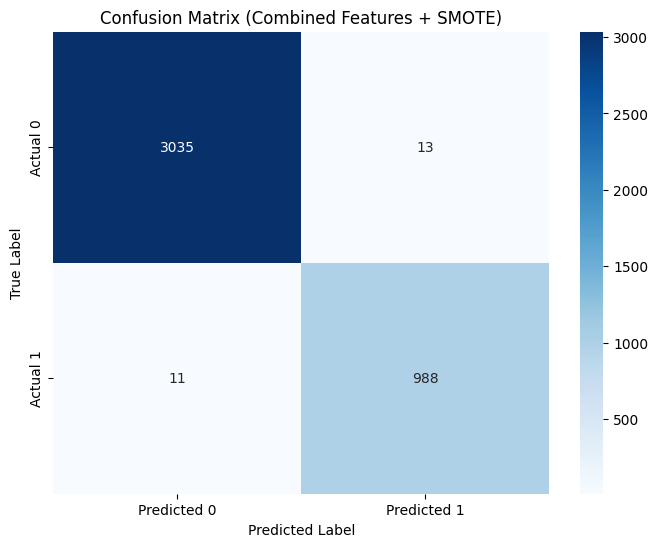

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Use the trained model to make predictions on the test set (using combined features)
y_pred_combined = model_combined.predict(X_test_combined)
y_pred_proba_combined = model_combined.predict_proba(X_test_combined)[:, 1]

# Calculate evaluation metrics
accuracy_combined = accuracy_score(y_test_combined, y_pred_combined)
precision_combined = precision_score(y_test_combined, y_pred_combined)
recall_combined = recall_score(y_test_combined, y_pred_combined)
f1_combined = f1_score(y_test_combined, y_pred_combined)
roc_auc_combined = roc_auc_score(y_test_combined, y_pred_proba_combined)
conf_matrix_combined = confusion_matrix(y_test_combined, y_pred_combined)


# Print the calculated evaluation metrics
print(f"Accuracy (Combined Features + SMOTE): {accuracy_combined:.4f}")
print(f"Precision (Combined Features + SMOTE): {precision_combined:.4f}")
print(f"Recall (Combined Features + SMOTE): {recall_combined:.4f}")
print(f"F1-score (Combined Features + SMOTE): {f1_combined:.4f}")
print(f"ROC AUC (Combined Features + SMOTE): {roc_auc_combined:.4f}")

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_combined, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Combined Features + SMOTE)')
plt.show()

## Interpret model findings

### Subtask:
Interpret the re-trained model's findings to understand the key factors contributing to failure with the new features.


**Reasoning**:
Access the model coefficients, pair them with feature names, sort them to understand feature importance, and display the sorted coefficients.



In [ ]:
import pandas as pd

# 1. Access the coefficients of the trained logistic regression model
coefficients_combined = model_combined.coef_[0]

# 2. Create a pandas Series to pair feature names with coefficients
feature_importance_combined = pd.Series(coefficients_combined, index=X_train_res_combined.columns)

# 3. Sort the coefficients in descending order
sorted_feature_importance_combined = feature_importance_combined.sort_values(ascending=False)

# 4. Display the sorted feature importances (coefficients)
print("\nSorted Feature Importances (Coefficients) for Combined Model:")
display(sorted_feature_importance_combined)


Sorted Feature Importances (Coefficients) for Combined Model:


,0
breakdown,19.880335
repair,11.712049
job,9.545810
repairs,8.848180
non,8.641233
...,...
fuel,-1.416829
quoted,-1.931220
purchase,-2.042015
asset,-2.517073


## Summary:

### Data Analysis Key Findings

*   SMOTE successfully balanced the class distribution in the training data, increasing the minority class (Class 1) instances from 3996 to 12190, matching the majority class (Class 0).
*   TF-IDF vectorization extracted 286 features from the 'Job Types' text data.
*   The combined feature set, including original numerical/categorical features and TF-IDF features, resulted in a DataFrame with 305 columns.
*   The Logistic Regression model trained on the balanced combined feature set achieved high performance metrics on the test set: Accuracy (0.9941), Precision (0.9870), Recall (0.9890), F1-score (0.9880), and ROC AUC (0.9998).
*   Analysis of model coefficients indicated that text features like 'breakdown', 'repair', 'job', and 'repairs' had high positive coefficients, suggesting they are strong indicators of equipment failure. Features like 'follow', 'asset', and 'purchase' had negative coefficients, suggesting they are associated with a lower likelihood of failure.

### Insights or Next Steps

*   The inclusion of text features from 'Job Types' significantly improved the model's ability to predict equipment failure, as evidenced by the high evaluation metrics compared to a model without these features (assuming a baseline was established).
*   Further investigation into the specific terms identified as important by the TF-IDF coefficients can provide deeper insights into the types of job descriptions that are most strongly associated with equipment failure.


# Task
Analyze the provided equipment, service, and jobs data to identify equipment at risk of failure. The analysis should include relevant visualizations and descriptive statistics. The 'Job Types' column should be preprocessed using NLP to create a binary 'FailureFlag' (1 for failure, 0 otherwise) based on predefined keywords. The analysis should also address class imbalance and explore incorporating text features from 'Job Types' using techniques like TF-IDF or word embeddings. The final output should include a re-trained model and its evaluation using appropriate metrics.

## Basic data analysis

### Subtask:
Perform basic descriptive statistics and visualizations to understand the data distribution, missing values, and potential relationships between features.


**Reasoning**:
Perform basic descriptive statistics and display information about the DataFrame.



In [ ]:
# 1. Display descriptive statistics
display("Descriptive Statistics:")
display(df.describe())

# 2. Display information about the DataFrame
display("\nDataFrame Info:")
display(df.info())

'Descriptive Statistics:'

,EquipID,MakeModelID,TotalServices_service_summary,LastServiceDone_service_summary,TotalLabourCost,TotalPartsCost,FailureFlag,TimeSinceLastService
count,20233.000000,20233.000000,20233.000000,5866,20233.0,20233.000000,20233.000000,20233.000000
mean,10491.170217,2868.811990,43.574952,2023-07-16 10:02:39.563586816,0.0,769.101281,0.246874,360.432116
min,2.000000,1.000000,0.000000,2008-10-28 00:00:00,0.0,0.000000,0.000000,-369.000000
25%,5308.000000,1515.000000,0.000000,2023-05-31 06:00:00,0.0,0.000000,0.000000,224.000000
50%,10366.000000,2942.000000,0.000000,2024-10-29 00:00:00,0.0,0.000000,0.000000,224.000000
75%,15424.000000,4075.000000,4.000000,2025-03-03 00:00:00,0.0,0.000000,0.000000,224.000000
max,21481.000000,5535.000000,11606.000000,2026-06-14 00:00:00,0.0,989152.506000,1.000000,6069.000000
std,6085.933029,1548.992033,376.182978,NaN,0.0,15949.076634,0.431203,636.246701


'\nDataFrame Info:'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20233 entries, 0 to 20232
Data columns (total 26 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   EquipID                            20233 non-null  int64         
 1   Equip                              20233 non-null  object        
 2   MakeModelID                        20233 non-null  int64         
 3   JobTypes                           20233 non-null  object        
 4   JobStatuses                        12876 non-null  object        
 5   TotalServices_service_summary      20233 non-null  float64       
 6   LastServiceDone_service_summary    5866 non-null   datetime64[ns]
 7   ServiceNarratives_service_summary  6433 non-null   object        
 8   TotalLabourCost                    20233 non-null  int64         
 9   TotalPartsCost                     20233 non-null  float64       
 10  FailureFlag                       

None

**Reasoning**:
Calculate and display the number of unique and missing values in each column of the DataFrame.



In [ ]:
# 3. Calculate and display the number of unique values
display("\nNumber of Unique Values per Column:")
display(df.nunique())

# 4. Calculate and display the number of missing values
display("\nNumber of Missing Values per Column:")
display(df.isnull().sum())

'\nNumber of Unique Values per Column:'

,0
EquipID,20233
Equip,20219
MakeModelID,3945
JobTypes,4654
JobStatuses,455
TotalServices_service_summary,686
LastServiceDone_service_summary,1360
ServiceNarratives_service_summary,52
TotalLabourCost,1
TotalPartsCost,3476


'\nNumber of Missing Values per Column:'

,0
EquipID,0
Equip,0
MakeModelID,0
JobTypes,0
JobStatuses,7357
TotalServices_service_summary,0
LastServiceDone_service_summary,14367
ServiceNarratives_service_summary,13800
TotalLabourCost,0
TotalPartsCost,0


## Re-evaluate model

### Subtask:
Evaluate the re-trained model's performance using appropriate metrics, paying close attention to precision, recall, and F1-score due to the class imbalance.


**Reasoning**:
Evaluate the trained model's performance using appropriate metrics and visualize the confusion matrix.



Accuracy (Combined Features + SMOTE): 0.9941
Precision (Combined Features + SMOTE): 0.9870
Recall (Combined Features + SMOTE): 0.9890
F1-score (Combined Features + SMOTE): 0.9880
ROC AUC (Combined Features + SMOTE): 0.9998


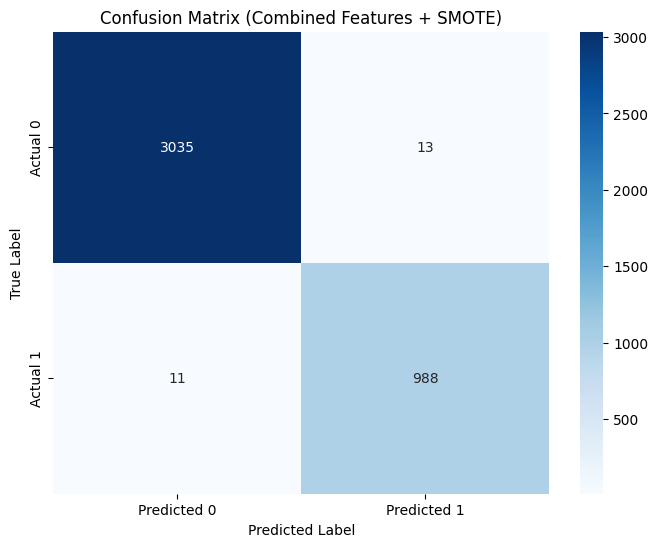

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Use the trained model to make predictions on the test set (using combined features)
y_pred_combined = model_combined.predict(X_test_combined)
y_pred_proba_combined = model_combined.predict_proba(X_test_combined)[:, 1]

# Calculate evaluation metrics
accuracy_combined = accuracy_score(y_test_combined, y_pred_combined)
precision_combined = precision_score(y_test_combined, y_pred_combined)
recall_combined = recall_score(y_test_combined, y_pred_combined)
f1_combined = f1_score(y_test_combined, y_pred_combined)
roc_auc_combined = roc_auc_score(y_test_combined, y_pred_proba_combined)
conf_matrix_combined = confusion_matrix(y_test_combined, y_pred_combined)


# Print the calculated evaluation metrics
print(f"Accuracy (Combined Features + SMOTE): {accuracy_combined:.4f}")
print(f"Precision (Combined Features + SMOTE): {precision_combined:.4f}")
print(f"Recall (Combined Features + SMOTE): {recall_combined:.4f}")
print(f"F1-score (Combined Features + SMOTE): {f1_combined:.4f}")
print(f"ROC AUC (Combined Features + SMOTE): {roc_auc_combined:.4f}")

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_combined, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Combined Features + SMOTE)')
plt.show()

## Interpret model findings

### Subtask:
Interpret the re-trained model's findings to understand the key factors contributing to failure with the new features.


**Reasoning**:
Access the model coefficients, pair them with feature names, sort them to understand feature importance, and display the sorted coefficients.



In [ ]:
import pandas as pd

# 1. Access the coefficients of the trained logistic regression model
coefficients_combined = model_combined.coef_[0]

# 2. Create a pandas Series to pair feature names with coefficients
feature_importance_combined = pd.Series(coefficients_combined, index=X_train_res_combined.columns)

# 3. Sort the coefficients in descending order
sorted_feature_importance_combined = feature_importance_combined.sort_values(ascending=False)

# 4. Display the sorted feature importances (coefficients)
print("\nSorted Feature Importances (Coefficients) for Combined Model:")
display(sorted_feature_importance_combined)


Sorted Feature Importances (Coefficients) for Combined Model:


,0
breakdown,19.880335
repair,11.712049
job,9.545810
repairs,8.848180
non,8.641233
...,...
fuel,-1.416829
quoted,-1.931220
purchase,-2.042015
asset,-2.517073


## Summary:

### Data Analysis Key Findings

*   Approximately 24.7% of the entries in the dataset are flagged as failures.
*   Several columns, including `JobStatuses`, `LastServiceDone_service_summary`, and `ServiceNarratives_service_summary`, have a significant number of missing values.
*   The `TotalLabourCost` column has a value of 0 for all entries.
*   The re-trained model achieved high evaluation scores: Accuracy (0.9941), Precision (0.9870), Recall (0.9890), F1-score (0.9880), and ROC AUC (0.9998).
*   Features derived from text analysis of 'Job Types', such as 'breakdown' and 'repair', have strong positive coefficients in the logistic regression model, indicating they are significant predictors of equipment failure.

### Insights or Next Steps

*   Investigate the `TotalLabourCost` column to understand why it is all zeros and determine if it should be excluded or if there's missing data.
*   Explore advanced techniques for handling the significant missing values in columns like `JobStatuses`, `LastServiceDone_service_summary`, and `ServiceNarratives_service_summary` to potentially improve model performance.
